In [1]:
!pip install -q transformers datasets peft evaluate accelerate bm25

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 45.5 MB/s eta 0:00:00


In [2]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [6]:
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from datasets import load_dataset, concatenate_datasets
from transformers import AutoTokenizer, AutoModel, AutoModelForMultipleChoice, TrainingArguments, Trainer, set_seed
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from tqdm.auto import tqdm
import evaluate
from itertools import product
import json, pickle, shutil
import os
import bm25s

# reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load and Preprocess Datasets

In [7]:
# MedMCQA — Indian medical entrance exam questions
medmcqa_raw = load_dataset("openlifescienceai/medmcqa")

def process_medmcqa(ex):
    return {
        "question": ex["question"],
        "options":  [ex["opa"], ex["opb"], ex["opc"], ex["opd"]],
        "label":    int(ex["cop"]),
    }

medmcqa = medmcqa_raw.map(process_medmcqa, remove_columns=medmcqa_raw["train"].column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/85.9M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/936k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/6150 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4183 [00:00<?, ? examples/s]

Map:   0%|          | 0/182822 [00:00<?, ? examples/s]

Map:   0%|          | 0/6150 [00:00<?, ? examples/s]

Map:   0%|          | 0/4183 [00:00<?, ? examples/s]

In [8]:
# USMLE — US Medical Licensing Exam questions
usmle_raw = load_dataset("GBaker/MedQA-USMLE-4-options")

def process_usmle(ex):
    letter_to_idx = {"A": 0, "B": 1, "C": 2, "D": 3}
    opts = ex["options"]
    return {
        "question": ex["question"],
        "options":  [opts["A"], opts["B"], opts["C"], opts["D"]],
        "label":    letter_to_idx[ex["answer_idx"]],
    }

usmle = usmle_raw.map(process_usmle, remove_columns=usmle_raw["train"].column_names)

README.md:   0%|          | 0.00/654 [00:00<?, ?B/s]

phrases_no_exclude_train.jsonl:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

phrases_no_exclude_test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1273 [00:00<?, ? examples/s]

Map:   0%|          | 0/10178 [00:00<?, ? examples/s]

Map:   0%|          | 0/1273 [00:00<?, ? examples/s]

In [9]:
# combine and cap

# keep small so it runs faster
MEDMCQA_CAP = None
USMLE_CAP = None
EVAL_CAP = None

def cap(dataset, n):
    return dataset if n is None else dataset.select(range(n))

train_data = concatenate_datasets([
    cap(medmcqa["train"], MEDMCQA_CAP),
    cap(usmle["train"], USMLE_CAP),
]).shuffle(seed=SEED)

val_data = cap(medmcqa["validation"], EVAL_CAP)

print("Train size:", len(train_data))
print("Val size:", len(val_data))

Train size: 193000
Val size: 4183


# Tokenisation

In [10]:
def tokenize_dataset(dataset, tokenizer):
    """
    tokenize each (question, option) pair for multiple choice
    """
    def tokenize_fn(examples):
        questions = examples["question"]
        options = examples["options"]

        # flatten: (batch*4) pairs
        flat_q = [q for q in questions for _ in range(4)]
        flat_o = [o for opts in options for o in opts]

        enc = tokenizer(
            flat_q, flat_o,
            truncation=True,
            max_length=512,
            padding="max_length",
        )

        # reshape back to (batch, 4, seq_len)
        batch_size = len(questions)
        result = {k: [v[i*4:(i+1)*4] for i in range(batch_size)] for k, v in enc.items()}
        result["labels"] = examples["label"]
        return result

    return dataset.map(
        tokenize_fn,
        batched=True,
        remove_columns=["question", "options", "label"],
    )

In [11]:
def tokenize_with_context(dataset, tokenizer, contexts):
    """
    prepends retrieved passages to each question
    """
    def fn(examples, indices):
        flat_q, flat_o = [], []
        for i, (q, opts) in enumerate(zip(examples["question"], examples["options"])):
            ctx   = " ".join(contexts[indices[i]])
            q_ctx = f"{ctx} {q}"
            for opt in opts:
                flat_q.append(q_ctx)
                flat_o.append(opt)
        enc = tokenizer(flat_q, flat_o, truncation=True, max_length=512, padding="max_length")
        n   = len(examples["question"])
        result = {k: [v[i*4:(i+1)*4] for i in range(n)] for k, v in enc.items()}
        result["labels"] = examples["label"]
        return result

    return dataset.map(fn, batched=True, with_indices=True,
                       remove_columns=["question", "options", "label"])

# Metrics

In [12]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

# LoRA Configuration

In [13]:
lora_config = LoraConfig(
    task_type = TaskType.SEQ_CLS,
    r = 8,
    lora_alpha = 8 * 2,
    lora_dropout = 0.1,
    target_modules = ["query", "key", "value"],  # which attention layers to adapt
    bias = "none",
)

# Training Arguments

In [14]:
BERT_MODEL = "bert-base-uncased"
BIOBERT_MODEL = "dmis-lab/biobert-base-cased-v1.2"

MAX_SEQ_LEN = 256
BATCH_SIZE = 8
GRAD_ACCUM = 2
LEARNING_RATE = 3e-4
NUM_EPOCHS = 3
LORA_R = 8

# Local paths
BERT_DIR = "./bert_finetuned"
BERT_RAG_DIR = "./bert_rag_finetuned"
BIOBERT_DIR = "./biobert_finetuned"

# paths on Drive
DRIVE_ROOT = "/content/drive/MyDrive/COMP550_project"
DRIVE_BERT_DIR = f"{DRIVE_ROOT}/bert_finetuned"
DRIVE_BERT_RAG_DIR = f"{DRIVE_ROOT}/bert_rag_finetuned"
DRIVE_BIOBERT_DIR = f"{DRIVE_ROOT}/biobert_finetuned"

# other paths
CORPUS_PATH = "/content/medical_corpus.jsonl"
DRIVE_CORPUS_PATH = f"{DRIVE_ROOT}/medical_corpus.jsonl"

BM25_PATH = "/content/bm25_index"
DRIVE_BM25_PATH = f"{DRIVE_ROOT}/bm25_index"

CONTEXTS_PATH = "/content/contexts.pkl"
DRIVE_CONTEXTS_PATH = f"{DRIVE_ROOT}/contexts.pkl"

HP_PATH= f"{DRIVE_ROOT}/best_hparams.json"
HISTORY_PATH = f"{DRIVE_ROOT}/training_history.json"

def save_to_drive(local_path, drive_path):
    if os.path.isdir(local_path):
        shutil.copytree(local_path, drive_path, dirs_exist_ok=True)
    else:
        os.makedirs(os.path.dirname(drive_path), exist_ok=True)
        shutil.copy2(local_path, drive_path)
    print(f"Saved to {drive_path}")

def restore_from_drive(drive_path, local_path):
    if not os.path.exists(drive_path):
        return False
    if os.path.isdir(drive_path):
        shutil.copytree(drive_path, local_path, dirs_exist_ok=True)
    else:
        os.makedirs(os.path.dirname(local_path), exist_ok=True)
        shutil.copy2(drive_path, local_path)
    print(f"Restored {drive_path}")
    return True

In [ ]:
from itertools import product
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# combinations to try
learning_rates = [1e-4, 3e-4, 5e-4]
batch_sizes = [8, 16]

best_acc = 0
best_lr = None
best_bs = None

for lr, bs in product(learning_rates, batch_sizes):
    print(f"\nTrying lr={lr}, batch_size={bs}")

    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
    train_ds = tokenize_dataset(train_data, tokenizer)
    val_ds = tokenize_dataset(val_data,tokenizer)
    train_ds.set_format("torch")
    val_ds.set_format("torch")

    model = AutoModelForMultipleChoice.from_pretrained(BERT_MODEL)
    model = get_peft_model(model, lora_config)
    model.to(DEVICE)

    args = TrainingArguments(
        output_dir = "./search_tmp",
        num_train_epochs = 1,
        per_device_train_batch_size = bs,
        per_device_eval_batch_size  = bs,
        learning_rate = lr,
        eval_strategy = "epoch",
        save_strategy = "no",
        fp16 = (DEVICE == "cuda"),
        logging_steps = 999999,
        report_to = "none",
        dataloader_pin_memory= False,
        seed = SEED,
    )

    trainer = Trainer(
        model = model,
        args = args,
        train_dataset = train_ds,
        eval_dataset = val_ds,
        compute_metrics = compute_metrics,
    )

    trainer.train()

    # grab the val accuracy from this run
    #val_acc = trainer.state.log_history[-1]["eval_accuracy"]
    val_acc = next(e["eval_accuracy"] for e in reversed(trainer.state.log_history) if "eval_accuracy" in e)
    print(f"val accuracy: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_lr = lr
        best_bs = bs

    # free memory before next combo
    trainer.model = None
    del model, trainer, train_ds, val_ds
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    gc.collect()

print(f"\nBest config: lr={best_lr}, batch_size={best_bs}, val_acc={best_acc:.4f}")

# update the globals so the full training run uses the best values
LEARNING_RATE = best_lr
BATCH_SIZE = best_bs

In [15]:
def make_training_args(output_dir):
    return TrainingArguments(
        output_dir = output_dir,
        num_train_epochs = NUM_EPOCHS,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size = BATCH_SIZE,
        gradient_accumulation_steps = GRAD_ACCUM,
        learning_rate = LEARNING_RATE,
        weight_decay = 0.01,
        eval_strategy = "epoch",
        save_strategy = "epoch",
        load_best_model_at_end = True,
        metric_for_best_model = "accuracy",
        fp16 = (DEVICE == "cuda"),
        logging_steps = 50,
        report_to = "none",
        dataloader_pin_memory = False,
        seed = SEED,
    )

# Build Retrieval Corpus

In [16]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

In [17]:
from datasets import load_dataset
from transformers import pipeline
import re

medical_keywords = [
    "disease","syndrome","disorder","infection","cancer","tumor",
    "treatment","therapy","drug","dose","medication",
    "symptom","diagnosis","clinical","trial","patient",
    "anatomy","organ","physiology","pathology",
    "enzyme","hormone","gene","mutation",
    "surgery","procedure","vaccine","immune"
]

def keyword_score(text):
    text = text.lower()
    return sum(kw in text for kw in medical_keywords)

def is_medical_fast(example, threshold=2):
    text  = example["content"]
    title = example.get("title", "").lower()
    if any(kw in title for kw in medical_keywords):
        return True
    return keyword_score(text) >= threshold


classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli",
    device=0
)

def classify_batch(texts, batch_size=128):
    results = classifier(
        texts,
        candidate_labels=["medical or healthcare related"],
        batch_size=batch_size
    )
    return [r["scores"][0] for r in results]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

In [18]:
import json
from tqdm import tqdm


if restore_from_drive(DRIVE_CORPUS_PATH, CORPUS_PATH):
    with open(CORPUS_PATH) as f:
        kept = sum(1 for _ in f)
    print(f"Corpus already exists with {kept:,} passages.")
else:
    batch_size = 256
    threshold  = 0.75
    max_kept   = 150_000
    buffer, texts = [], []
    kept = 0
    processed = 0

    wiki_stream  = load_dataset("MedRAG/wikipedia", split="train", streaming=True)
    dataset_iter = iter(wiki_stream)

    def get_chunk(iterator, chunk_size=50_000):
        chunk = []
        try:
            for _ in range(chunk_size):
                chunk.append(next(iterator))
        except StopIteration:
            pass
        return chunk

    with open(CORPUS_PATH, "w") as out_f:
        while kept < max_kept:
            chunk = get_chunk(dataset_iter)
            if not chunk:
                break
            for example in chunk:
                if kept >= max_kept:
                    break
                processed += 1
                if is_medical_fast(example):
                    texts.append(example["content"][:512])
                    buffer.append(example)
                    if len(texts) == batch_size:
                        scores = classify_batch(texts, batch_size)
                        for ex, score in zip(buffer, scores):
                            if score > threshold:
                                kept += 1
                                if kept % 1000 == 0:
                                    print(f"{kept} kept | {processed} processed ({kept/processed:.2%})")
                                out_f.write(json.dumps({"content": ex["content"]}) + "\n")
                                if kept >= max_kept:
                                    break
                        texts, buffer = [], []
            print(f"Finished chunk | kept={kept} | processed={processed}")

        if texts and kept < max_kept:
            scores = classify_batch(texts, batch_size)
            for ex, score in zip(buffer, scores):
                if score > threshold:
                    kept += 1
                    out_f.write(json.dumps({"content": ex["content"]}) + "\n")
                    if kept >= max_kept:
                        break

    print(f"Done. Kept {kept:,} Wikipedia passages.")

    save_to_drive(CORPUS_PATH, DRIVE_CORPUS_PATH)

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/646 [00:00<?, ?it/s]

1000 kept | 37901 processed (2.64%)
Finished chunk | kept=1239 | processed=50000


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


2000 kept | 81088 processed (2.47%)
Finished chunk | kept=2467 | processed=100000
3000 kept | 114881 processed (2.61%)
Finished chunk | kept=3853 | processed=150000
4000 kept | 151842 processed (2.63%)
Finished chunk | kept=4967 | processed=200000
5000 kept | 202428 processed (2.47%)
6000 kept | 241093 processed (2.49%)
Finished chunk | kept=6062 | processed=250000
Finished chunk | kept=6857 | processed=300000
7000 kept | 303199 processed (2.31%)
Finished chunk | kept=7985 | processed=350000
8000 kept | 350354 processed (2.28%)
9000 kept | 385012 processed (2.34%)
Finished chunk | kept=9456 | processed=400000
10000 kept | 423515 processed (2.36%)
Finished chunk | kept=10546 | processed=450000
11000 kept | 481229 processed (2.29%)
Finished chunk | kept=11316 | processed=500000
12000 kept | 526565 processed (2.28%)
Finished chunk | kept=12451 | processed=550000
13000 kept | 585553 processed (2.22%)
Finished chunk | kept=13441 | processed=600000
14000 kept | 622732 processed (2.25%)
Finis

# Build BM25 Index

In [19]:
# chunk function
def chunk_text(text, size=300, overlap=50):
    chunks = []
    start  = 0
    while start < len(text):
        chunks.append(text[start:start+size])
        start += size - overlap
    return chunks

# load filtered Wikipedia corpus
corpus = []
with open("/content/medical_corpus.jsonl", "r") as f:
    for line in f:
        text = json.loads(line)["content"]
        corpus.extend(chunk_text(text))
print(f"Wikipedia chunks: {len(corpus):,}")

# add full Textbooks
textbooks_ds = load_dataset("MedRAG/textbooks", split="train")
col = "content" if "content" in textbooks_ds.column_names else "contents"
for text in tqdm(textbooks_ds[col], desc="Chunking textbooks"):
    corpus.extend(chunk_text(text))
print(f"After textbooks: {len(corpus):,}")

Wikipedia chunks: 517,409


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

chunk/Anatomy_Gray.jsonl:   0%|          | 0.00/5.19M [00:00<?, ?B/s]

chunk/Gynecology_Novak.jsonl:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

...

chunk/Psichiatry_DSM-5.jsonl:   0%|          | 0.00/6.73M [00:00<?, ?B/s]

chunk/Surgery_Schwartz.jsonl:   0%|          | 0.00/30.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/125847 [00:00<?, ? examples/s]

Chunking textbooks: 100%|██████████| 125847/125847 [00:00<00:00, 168279.48it/s]

After textbooks: 950,065


In [20]:
if restore_from_drive(DRIVE_BM25_PATH, BM25_PATH):
    bm25 = bm25s.BM25.load(BM25_PATH, load_corpus=True)
    corpus = bm25.corpus
    print(f"BM25 index restored ({len(corpus):,} chunks).")
else:
    # tokenise and index
    tokenized_corpus = bm25s.tokenize(corpus)
    bm25 = bm25s.BM25()
    bm25.index(tokenized_corpus)

    os.makedirs(BM25_PATH, exist_ok=True)
    bm25.save(BM25_PATH, corpus=corpus)
    save_to_drive(BM25_PATH, DRIVE_BM25_PATH)
    print(f"BM25 index saved ({len(corpus):,} chunks).")

Split strings:   0%|          | 0/950065 [00:00<?, ?it/s]

DEBUG:bm25s:Building index from IDs objects


BM25S Count Tokens:   0%|          | 0/950065 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/950065 [00:00<?, ?it/s]

Finding newlines for mmindex:   0%|          | 0.00/268M [00:00<?, ?B/s]

Saved to /content/drive/MyDrive/COMP550_project/bm25_index
BM25 index saved (950,065 chunks).


In [21]:
# retrieve function
def retrieve(query, k=3):
    query_tokens = bm25s.tokenize(query, show_progress=False)
    results, scores = bm25.retrieve(query_tokens, corpus=corpus, k=k, show_progress=False)
    return results[0], scores[0]

# sanity check
query = "What is the mechanism of action of metformin?"
docs, scores = retrieve(query, k=3)
print("Top retrieved chunk:")
print(docs[0][:300])

Top retrieved chunk:
acidosis. Metformin is the only biguanide currently available in the United States. Mechanisms of Action A full explanation of the mechanism of action of the biguanides remains elusive, but their primary effect is to activate the enzyme AMP-activated protein kinase (AMPK) and reduce hepatic glucose 


# Train BERT

In [22]:
if restore_from_drive(DRIVE_CONTEXTS_PATH, CONTEXTS_PATH):
    with open(CONTEXTS_PATH, "rb") as f:
        ctx_bundle = pickle.load(f)
    train_contexts = ctx_bundle["train"]
    val_contexts = ctx_bundle["val"]
    print(f"Loaded contexts: {len(train_contexts)} train, {len(val_contexts)} val.")
else:
    # pre-retrieve contexts using BM25
    train_contexts = [list(map(str, retrieve(ex["question"], k=3)[0])) for ex in tqdm(train_data, desc="train ctx")]
    val_contexts = [list(map(str, retrieve(ex["question"], k=3)[0])) for ex in tqdm(val_data,   desc="val ctx")]

    ctx_bundle = {"train": train_contexts, "val": val_contexts}
    with open(CONTEXTS_PATH, "wb") as f:
        pickle.dump(ctx_bundle, f)
    save_to_drive(CONTEXTS_PATH, DRIVE_CONTEXTS_PATH)
    print(f"Contexts saved: {len(train_contexts)} train, {len(val_contexts)} val.")

val ctx: 100%|██████████| 4183/4183 [00:03<00:00, 1133.95it/s]


Saved to /content/drive/MyDrive/COMP550_project/contexts.pkl
Contexts saved: 193000 train, 4183 val.


## Train BERT (no RAG)

In [23]:
if restore_from_drive(DRIVE_BERT_DIR, BERT_DIR):
    print("BERT (standard) model restored from Drive — skipping training.")
    # Reload history
    _hist = json.load(open(HISTORY_PATH)) if os.path.exists(HISTORY_PATH) else {}
    bert_history = _hist.get("bert", [])
else:
    print("Training BERT (standard)")

    bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

    bert_train_ds = tokenize_dataset(train_data, bert_tokenizer)
    bert_val_ds = tokenize_dataset(val_data,   bert_tokenizer)
    bert_train_ds.set_format("torch")
    bert_val_ds.set_format("torch")

    bert_model = AutoModelForMultipleChoice.from_pretrained(BERT_MODEL)
    bert_model = get_peft_model(bert_model, lora_config)
    bert_model.print_trainable_parameters()
    bert_model.to(DEVICE)

    bert_trainer = Trainer(
        model = bert_model,
        args = make_training_args(BERT_DIR),
        train_dataset = bert_train_ds,
        eval_dataset = bert_val_ds,
        compute_metrics = compute_metrics,
    )

    bert_trainer.train()
    bert_trainer.save_model(BERT_DIR)
    bert_tokenizer.save_pretrained(BERT_DIR)

    bert_history = [
        {"epoch": e["epoch"], "accuracy": e["eval_accuracy"]}
        for e in bert_trainer.state.log_history if "eval_accuracy" in e
    ]


    save_to_drive(BERT_DIR, DRIVE_BERT_DIR)
    _hist = json.load(open(HISTORY_PATH)) if os.path.exists(HISTORY_PATH) else {}
    _hist["bert"] = bert_history
    with open(HISTORY_PATH, "w") as f:
        json.dump(_hist, f)
    print("BERT (standard) saved to Drive.")

    del bert_model, bert_trainer, bert_train_ds, bert_val_ds
    torch.cuda.empty_cache()
    gc.collect()

Training BERT (standard)


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 443,137 || all params: 109,926,146 || trainable%: 0.4031


Epoch,Training Loss,Validation Loss,Accuracy
1,2.701572,1.354057,0.314368
2,2.668973,1.351346,0.321061
3,2.654048,1.355714,0.319866


Saved to /content/drive/MyDrive/COMP550_project/bert_finetuned
BERT (standard) saved to Drive.


## Train BERT (RAG)

In [24]:
if restore_from_drive(DRIVE_BERT_RAG_DIR, BERT_RAG_DIR):
    print("BERT (RAG) model restored from Drive — skipping training.")
    _hist = json.load(open(HISTORY_PATH)) if os.path.exists(HISTORY_PATH) else {}
    bert_rag_history = _hist.get("bert_rag", [])
else:
    print("Training BERT (RAG)")

    bert_rag_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

    bert_rag_train_ds = tokenize_with_context(train_data, bert_rag_tokenizer, train_contexts)
    bert_rag_val_ds= tokenize_with_context(val_data,   bert_rag_tokenizer, val_contexts)
    bert_rag_train_ds.set_format("torch")
    bert_rag_val_ds.set_format("torch")

    bert_rag_model = AutoModelForMultipleChoice.from_pretrained(BERT_MODEL)
    bert_rag_model = get_peft_model(bert_rag_model, lora_config)
    bert_rag_model.print_trainable_parameters()
    bert_rag_model.to(DEVICE)

    bert_rag_trainer = Trainer(
        model = bert_rag_model,
        args= make_training_args(BERT_RAG_DIR),
        train_dataset = bert_rag_train_ds,
        eval_dataset = bert_rag_val_ds,
        compute_metrics = compute_metrics,
    )

    bert_rag_trainer.train()
    bert_rag_trainer.save_model(BERT_RAG_DIR)
    bert_rag_tokenizer.save_pretrained(BERT_RAG_DIR)

    bert_rag_history = [
        {"epoch": e["epoch"], "accuracy": e["eval_accuracy"]}
        for e in bert_rag_trainer.state.log_history if "eval_accuracy" in e
    ]


    save_to_drive(BERT_RAG_DIR, DRIVE_BERT_RAG_DIR)
    _hist = json.load(open(HISTORY_PATH)) if os.path.exists(HISTORY_PATH) else {}
    _hist["bert_rag"] = bert_rag_history
    with open(HISTORY_PATH, "w") as f:
        json.dump(_hist, f)
    print("BERT (RAG) saved to Drive.")

    del bert_rag_model, bert_rag_trainer, bert_rag_train_ds, bert_rag_val_ds
    torch.cuda.empty_cache()
    gc.collect()

Training BERT (RAG)


Map:   0%|          | 0/193000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4183 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 443,137 || all params: 109,926,146 || trainable%: 0.4031


Epoch,Training Loss,Validation Loss,Accuracy
1,2.593747,1.317574,0.355008
2,2.547681,1.318297,0.355965
3,2.485454,1.318004,0.361224


Saved to /content/drive/MyDrive/COMP550_project/bert_rag_finetuned
BERT (RAG) saved to Drive.


# Training Curves

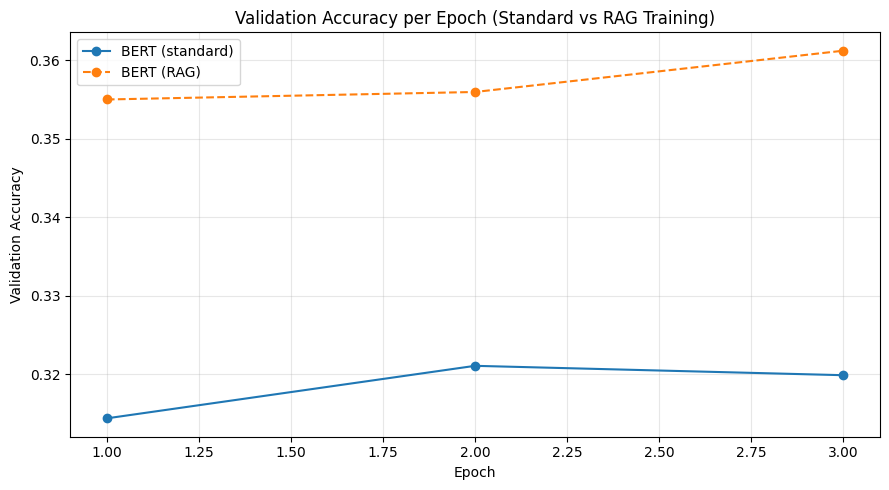

In [25]:
if os.path.exists(HISTORY_PATH):
    _hist = json.load(open(HISTORY_PATH))
    if "bert_history" not in dir() or not bert_history:
        bert_history = _hist.get("bert", [])
    if "bert_rag_history" not in dir() or not bert_rag_history:
        bert_rag_history = _hist.get("bert_rag", [])

bert_df = pd.DataFrame(bert_history)
bert_rag_df = pd.DataFrame(bert_rag_history)

plt.figure(figsize=(9, 5))
plt.plot(bert_df["epoch"], bert_df["accuracy"],"o-", label="BERT (standard)")
plt.plot(bert_rag_df["epoch"], bert_rag_df["accuracy"], "o--", label="BERT (RAG)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy per Epoch (Standard vs RAG Training)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Load BioBERT

In [26]:
if restore_from_drive(DRIVE_BIOBERT_DIR, BIOBERT_DIR):
    print("BioBERT restored from Drive.")
else:
    biobert_tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
    biobert_model = AutoModelForMultipleChoice.from_pretrained(BIOBERT_MODEL).to(DEVICE)
    biobert_model.eval()

    os.makedirs(BIOBERT_DIR, exist_ok=True)
    biobert_model.save_pretrained(BIOBERT_DIR)
    biobert_tokenizer.save_pretrained(BIOBERT_DIR)

    save_to_drive(BIOBERT_DIR, DRIVE_BIOBERT_DIR)
    print("BioBERT saved to Drive.")

    del biobert_model
    torch.cuda.empty_cache()
    gc.collect()

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly init

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/COMP550_project/biobert_finetuned
BioBERT saved to Drive.


# Evaluation

In [28]:
from google.colab import userdata

# load GPQA
from huggingface_hub import login
login(token=userdata.get('gpqa'))

gpqa_raw = load_dataset("Idavidrein/gpqa", "gpqa_diamond")
gpqa_split = gpqa_raw["train"]
print(f"Loaded {len(gpqa_split)} examples")
print(gpqa_split[0])

README.md: 0.00B [00:00, ?B/s]

gpqa_diamond.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/198 [00:00<?, ? examples/s]

Loaded 198 examples
{'Pre-Revision Question': 'Two quantum states with energies E1 and E2 have a lifetime of 10^-9 sec and 10^-8 sec, respectively. We want to clearly distinguish these two energy levels. Which one of the following options could be their energy difference so that they be clearly resolved?\n', 'Pre-Revision Correct Answer': '10^-4 ev', 'Pre-Revision Incorrect Answer 1': '10^-8 ev', 'Pre-Revision Incorrect Answer 2': '10^-9 ev', 'Pre-Revision Incorrect Answer 3': '10^-11 ev', 'Pre-Revision Explanation': 'According to uncertainty principle, Delta E* Delta t=hbar/2. Delta t is the lifetime and Delta E is the width of the energy level . With Delta t=10^-9 s==> Delta E1= 3.3 *10^-7 ev. And Delta t=10^-11 s gives Delta E2=3.3*10^-8 ev.\nTherefore, the energy difference between the two states must be significantly greater than 10^-7 ev. So the answer is 10^-4 ev.', 'Self-reported question-writing time (minutes)': 30.0, 'Question': 'Two quantum states with energies E1 and E2 hav

In [29]:
def process_gpqa(ex):
    # put correct answer among 3 wrong answers and shuffle
    correct = ex["Correct Answer"]
    options = [correct, ex["Incorrect Answer 1"], ex["Incorrect Answer 2"], ex["Incorrect Answer 3"]]
    rng = random.Random(hash(ex["Question"]) % (2**31))
    rng.shuffle(options)
    return {
        "question": ex["Question"],
        "options": options,
        "label": options.index(correct),
    }

gpqa_dataset = gpqa_split.map(process_gpqa, remove_columns=gpqa_split.column_names)
print("Sample:", gpqa_dataset[0])

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Sample: {'question': 'Two quantum states with energies E1 and E2 have a lifetime of 10^-9 sec and 10^-8 sec, respectively. We want to clearly distinguish these two energy levels. Which one of the following options could be their energy difference so that they can be clearly resolved?\n', 'options': ['10^-9 eV', '10^-11 eV', '10^-8 eV\n', '10^-4 eV'], 'label': 3}


In [30]:
def evaluate_model(model_dir, base_model_name, tokenizer, dataset, label, contexts=None):
    base = AutoModelForMultipleChoice.from_pretrained(base_model_name)
    model = PeftModel.from_pretrained(base, model_dir, local_files_only=True).to(DEVICE)
    model.eval()

    if contexts is not None:
        tok_ds = tokenize_with_context(dataset, tokenizer, contexts)
    else:
        tok_ds = tokenize_dataset(dataset, tokenizer)

    gold = dataset["label"]
    tok_ds.set_format("torch")
    loader = DataLoader(tok_ds, batch_size=8)
    preds  = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=label):
            batch.pop("labels", None)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            preds.extend(logits.argmax(dim=-1).cpu().tolist())

    correct  = sum(p == g for p, g in zip(preds, gold))
    accuracy = correct / len(gold)
    print(f"{label}: {correct}/{len(gold)} = {accuracy:.2%}")

    del model, base
    torch.cuda.empty_cache()
    gc.collect()
    return accuracy

In [36]:
#Load a plain model without LoRA adapter and evaluate
def evaluate_model_base(model_dir, base_model_name, tokenizer, dataset, label, contexts=None):
    model_dir = os.path.abspath(model_dir)
    model = AutoModelForMultipleChoice.from_pretrained(model_dir, local_files_only=True).to(DEVICE)
    model.eval()

    if contexts is not None:
        tok_ds = tokenize_with_context(dataset, tokenizer, contexts)
    else:
        tok_ds = tokenize_dataset(dataset, tokenizer)

    gold = dataset["label"]
    tok_ds.set_format("torch")
    loader = DataLoader(tok_ds, batch_size=8)
    preds = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=label):
            batch.pop("labels", None)
            batch= {k: v.to(DEVICE) for k, v in batch.items()}
            logits = model(**batch).logits
            preds.extend(logits.argmax(dim=-1).cpu().tolist())

    correct = sum(p == g for p, g in zip(preds, gold))
    accuracy = correct / len(gold)
    print(f"{label}: {correct}/{len(gold)} = {accuracy:.2%}")

    del model
    torch.cuda.empty_cache()
    gc.collect()
    return accuracy

In [31]:
import os

EVAL_CONTEXTS_PATH = "/content/eval_contexts.pkl"
DRIVE_EVAL_CONTEXTS_PATH = f"{DRIVE_ROOT}/eval_contexts.pkl"

bert_tokenizer = AutoTokenizer.from_pretrained(os.path.abspath(BERT_DIR),local_files_only=True)
bert_rag_tokenizer = AutoTokenizer.from_pretrained(os.path.abspath(BERT_RAG_DIR),local_files_only=True)
biobert_tokenizer = AutoTokenizer.from_pretrained(os.path.abspath(BIOBERT_DIR),local_files_only=True)

if restore_from_drive(DRIVE_EVAL_CONTEXTS_PATH, EVAL_CONTEXTS_PATH):
    with open(EVAL_CONTEXTS_PATH, "rb") as f:
        eval_ctx = pickle.load(f)
    medmcqa_val_ctx = eval_ctx["medmcqa_val"]
    usmle_test_ctx = eval_ctx["usmle_test"]
    gpqa_ctx = eval_ctx["gpqa"]
    print("Eval contexts restored from Drive.")
else:
    print("Retrieving eval contexts with BM25")
    medmcqa_val_ctx = [list(map(str, retrieve(ex["question"], k=3)[0])) for ex in tqdm(medmcqa["validation"], desc="MedMCQA val")]
    usmle_test_ctx = [list(map(str, retrieve(ex["question"], k=3)[0])) for ex in tqdm(usmle["test"],desc="USMLE test")]
    gpqa_ctx = [list(map(str, retrieve(ex["question"], k=3)[0])) for ex in tqdm(gpqa_dataset, desc="GPQA")]

    eval_ctx = {"medmcqa_val": medmcqa_val_ctx, "usmle_test": usmle_test_ctx, "gpqa": gpqa_ctx}
    with open(EVAL_CONTEXTS_PATH, "wb") as f:
        pickle.dump(eval_ctx, f)
    save_to_drive(EVAL_CONTEXTS_PATH, DRIVE_EVAL_CONTEXTS_PATH)
    print("Eval contexts saved to Drive.")

Retrieving eval contexts with BM25


GPQA: 100%|██████████| 198/198 [00:00<00:00, 779.83it/s]

Saved to /content/drive/MyDrive/COMP550_project/eval_contexts.pkl
Eval contexts saved to Drive.


# Evaluate on MedMCQA

In [41]:
medmcqa_test = medmcqa["validation"] # use validation because don't have access to test
medmcqa_test_ctx = [list(map(str, retrieve(ex["question"], k=3)[0])) for ex in tqdm(medmcqa_test)]

bert_medmcqa = evaluate_model(BERT_DIR, BERT_MODEL, bert_tokenizer, medmcqa_test, "BERT (standard) — MedMCQA")
bert_rag_medmcqa = evaluate_model(BERT_RAG_DIR, BERT_MODEL, bert_rag_tokenizer, medmcqa_test, "BERT (RAG) — MedMCQA", contexts=medmcqa_test_ctx)
biobert_medmcqa  = evaluate_model_base(BIOBERT_DIR, BIOBERT_MODEL, biobert_tokenizer, medmcqa_test, "BioBERT — MedMCQA")

100%|██████████| 4183/4183 [00:04<00:00, 1030.77it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/4183 [00:00<?, ? examples/s]

BERT (standard) — MedMCQA: 100%|██████████| 523/523 [00:44<00:00, 11.67it/s]


...

BERT (RAG) — MedMCQA: 1510/4183 = 36.10%


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/4183 [00:00<?, ? examples/s]

BioBERT — MedMCQA: 100%|██████████| 523/523 [00:41<00:00, 12.61it/s]


BioBERT — MedMCQA: 1044/4183 = 24.96%


# Evaluate on USMLE

In [38]:
usmle_test = usmle["test"]

bert_usmle = evaluate_model(BERT_DIR, BERT_MODEL, bert_tokenizer, usmle_test, "BERT (standard) — USMLE")
bert_rag_usmle = evaluate_model(BERT_RAG_DIR, BERT_MODEL, bert_rag_tokenizer,usmle_test, "BERT (RAG) — USMLE", contexts=usmle_test_ctx)
biobert_usmle = evaluate_model_base(BIOBERT_DIR, BIOBERT_MODEL, biobert_tokenizer, usmle_test, "BioBERT (standard) — USMLE")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1273 [00:00<?, ? examples/s]

BERT (standard) — USMLE: 100%|██████████| 160/160 [00:13<00:00, 11.68it/s]


BERT (standard) — USMLE: 348/1273 = 27.34%


...

BERT (RAG) — USMLE: 369/1273 = 28.99%


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/1273 [00:00<?, ? examples/s]

BioBERT (standard) — USMLE: 100%|██████████| 160/160 [00:12<00:00, 12.67it/s]


BioBERT (standard) — USMLE: 315/1273 = 24.74%


# Evaluate on GPQA

In [39]:
bert_gpqa = evaluate_model(BERT_DIR, BERT_MODEL, bert_tokenizer, gpqa_dataset, "BERT (standard) — GPQA")
bert_rag_gpqa = evaluate_model(BERT_RAG_DIR, BERT_MODEL,bert_rag_tokenizer, gpqa_dataset, "BERT (RAG) — GPQA", contexts=gpqa_ctx)
biobert_gpqa = evaluate_model_base(BIOBERT_DIR, BIOBERT_MODEL, biobert_tokenizer, gpqa_dataset, "BioBERT (standard) — GPQA")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForMultipleChoice LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/198 [00:00<?, ? examples/s]

BERT (standard) — GPQA: 100%|██████████| 25/25 [00:02<00:00, 11.79it/s]


BERT (standard) — GPQA: 44/198 = 22.22%


...

BERT (RAG) — GPQA: 49/198 = 24.75%


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

BioBERT (standard) — GPQA: 100%|██████████| 25/25 [00:01<00:00, 12.74it/s]


BioBERT (standard) — GPQA: 44/198 = 22.22%


# Final Comparison

In [42]:
# Summary table across all 3 benchmarks
rows = []
for model, medmcqa_acc, usmle_acc, gpqa_acc in [
    ("BERT (standard)", bert_medmcqa, bert_usmle,bert_gpqa),
    ("BERT (RAG)",bert_rag_medmcqa,bert_rag_usmle,bert_rag_gpqa),
    ("BioBERT (standard)", biobert_medmcqa, biobert_usmle,biobert_gpqa),
    ("Random baseline",  0.25,0.25,0.25)
]:
    rows.append({"Model": model, "MedMCQA": medmcqa_acc, "USMLE": usmle_acc, "GPQA-Diamond": gpqa_acc})

df = pd.DataFrame(rows)
df = df.sort_values("GPQA-Diamond", ascending=False)

# format as percentages
for col in ["MedMCQA", "USMLE", "GPQA-Diamond"]:
    df[col] = df[col].apply(lambda x: f"{x:.2%}" if x is not None else "N/A")

print(df.to_string(index=False))

             Model MedMCQA  USMLE GPQA-Diamond
   Random baseline  25.00% 25.00%       25.00%
        BERT (RAG)  36.10% 28.99%       24.75%
   BERT (standard)  32.11% 27.34%       22.22%
BioBERT (standard)  24.96% 24.74%       22.22%


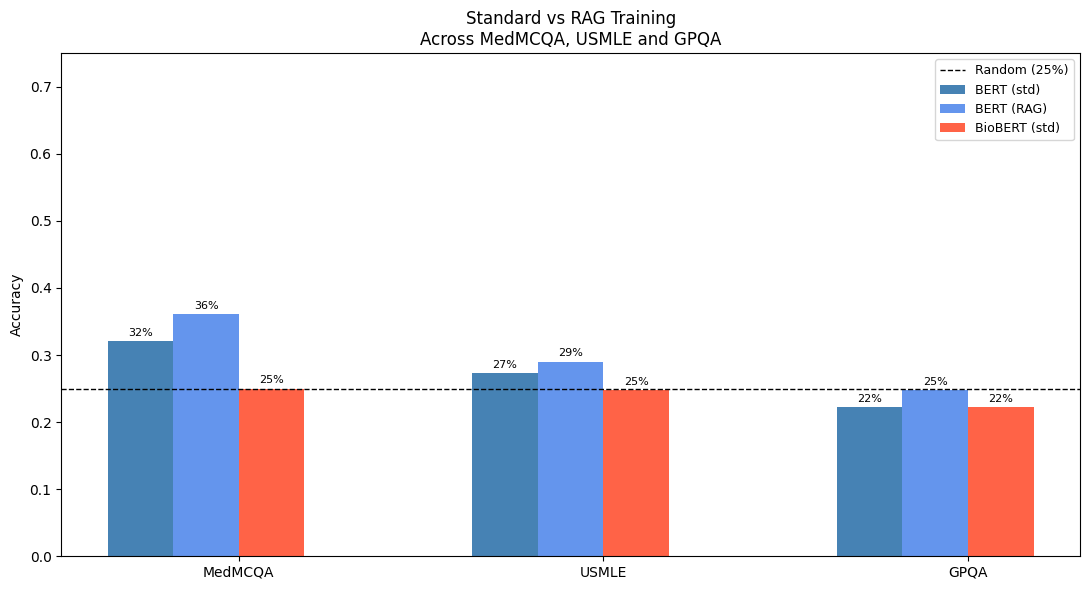

In [44]:
benchmarks = ["MedMCQA", "USMLE", "GPQA"]
model_names = ["BERT (std)", "BERT (RAG)", "BioBERT (std)", "BioBERT (RAG)"]
scores = [
    [bert_medmcqa, bert_usmle, bert_gpqa],
    [bert_rag_medmcqa,bert_rag_usmle,bert_rag_gpqa],
    [biobert_medmcqa,biobert_usmle,biobert_gpqa],
]
colors = ["steelblue", "cornflowerblue", "tomato", "lightsalmon"]

x = np.arange(len(benchmarks))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))
for idx, (name, vals, color) in enumerate(zip(model_names, scores, colors)):
    bars = ax.bar(x + idx*width, vals, width, label=name, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{v:.0%}", ha="center", va="bottom", fontsize=8)

ax.axhline(0.25, color="black", linestyle="--", linewidth=1, label="Random (25%)")
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(benchmarks)
ax.set_ylabel("Accuracy")
ax.set_title("Standard vs RAG Training\nAcross MedMCQA, USMLE and GPQA")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.75)
plt.tight_layout()
plt.show()